In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# for QQ plot
import scipy.stats as stats

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.preprocessing import PowerTransformer

In [4]:
df = pd.read_csv("concrete_data.csv")

In [5]:
df.head(5)

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [6]:
df.describe()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Cement              1030 non-null   float64
 1   Blast Furnace Slag  1030 non-null   float64
 2   Fly Ash             1030 non-null   float64
 3   Water               1030 non-null   float64
 4   Superplasticizer    1030 non-null   float64
 5   Coarse Aggregate    1030 non-null   float64
 6   Fine Aggregate      1030 non-null   float64
 7   Age                 1030 non-null   int64  
 8   Strength            1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.6 KB


In [8]:
df.shape

(1030, 9)

In [9]:
df.isnull().sum()

,0
Cement,0
Blast Furnace Slag,0
Fly Ash,0
Water,0
Superplasticizer,0
Coarse Aggregate,0
Fine Aggregate,0
Age,0
Strength,0


In [10]:
# extracting the x and y
X = df.drop(columns=['Strength'])
y = df.iloc[:,-1]

In [11]:
# Data Preprocessing
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [12]:
X_train

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age
995,158.6,148.9,116.0,175.1,15.0,953.3,719.7,28
507,424.0,22.0,132.0,178.0,8.5,822.0,750.0,28
334,275.1,0.0,121.4,159.5,9.9,1053.6,777.5,3
848,252.0,97.0,76.0,194.0,8.0,835.0,821.0,28
294,168.9,42.2,124.3,158.3,10.8,1080.8,796.2,3
...,...,...,...,...,...,...,...,...
87,286.3,200.9,0.0,144.7,11.2,1004.6,803.7,3
330,246.8,0.0,125.1,143.3,12.0,1086.8,800.9,14
466,190.3,0.0,125.2,166.6,9.9,1079.0,798.9,100
121,475.0,118.8,0.0,181.1,8.9,852.1,781.5,28


In [13]:
y_train

,Strength
995,27.68
507,62.05
334,23.80
848,33.40
294,7.40
...,...
87,24.40
330,42.22
466,33.56
121,68.30


In [14]:
# appltying Regression without any transformation
lr = LinearRegression()

lr.fit(X_train,y_train)
y_pred = lr.predict(X_test)

r2_score(y_test,y_pred)


0.627553179231485

In [15]:
# cross validation
lr = LinearRegression()
np.mean(cross_val_score(lr,X,y, scoring='r2'))

np.float64(0.46099404916628606)

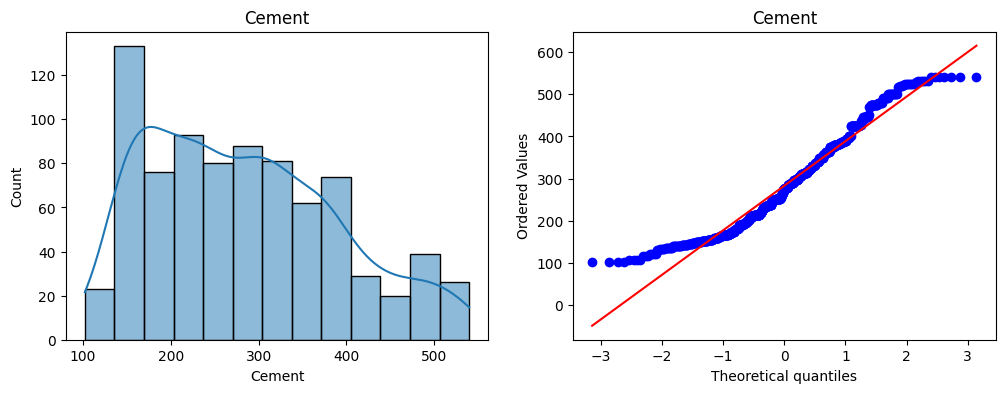

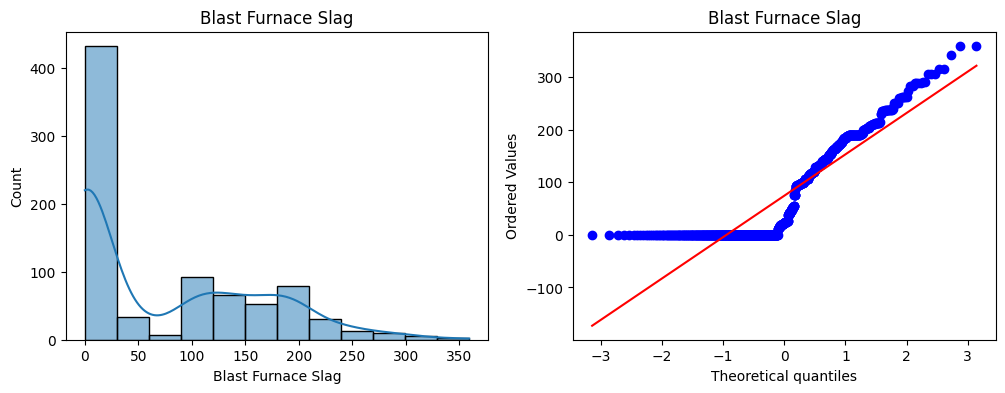

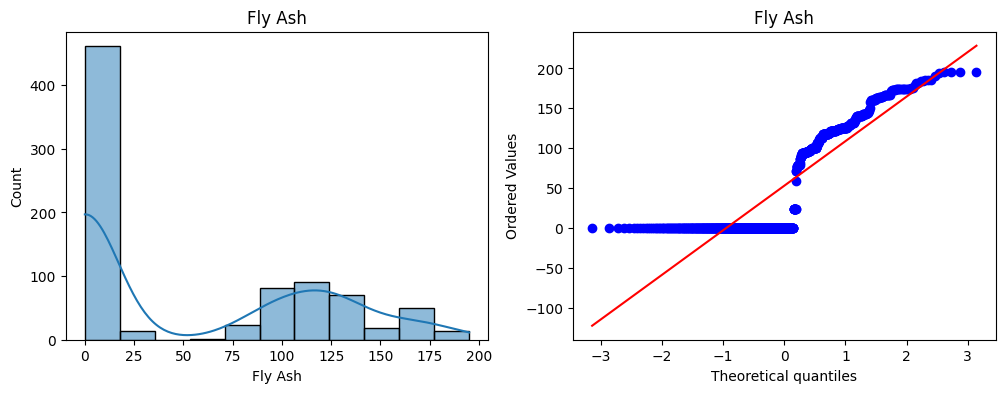

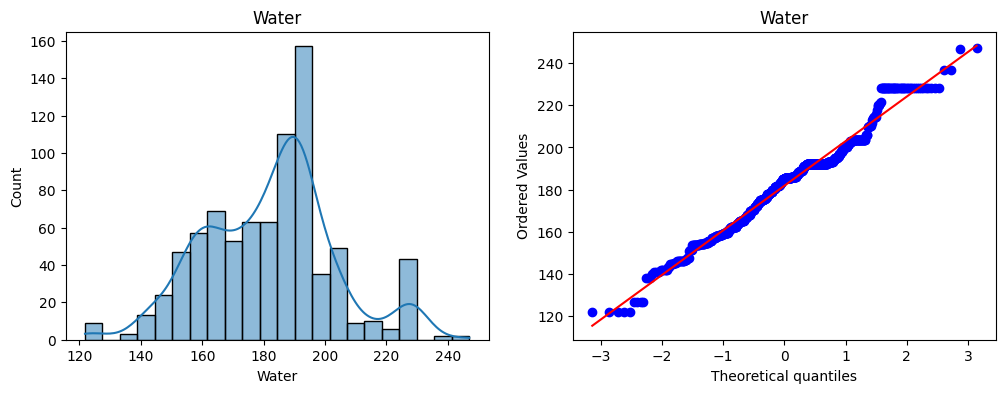

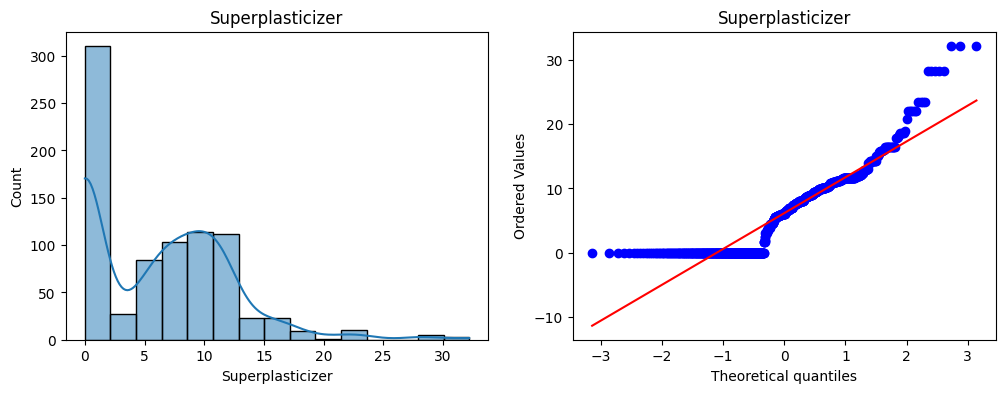

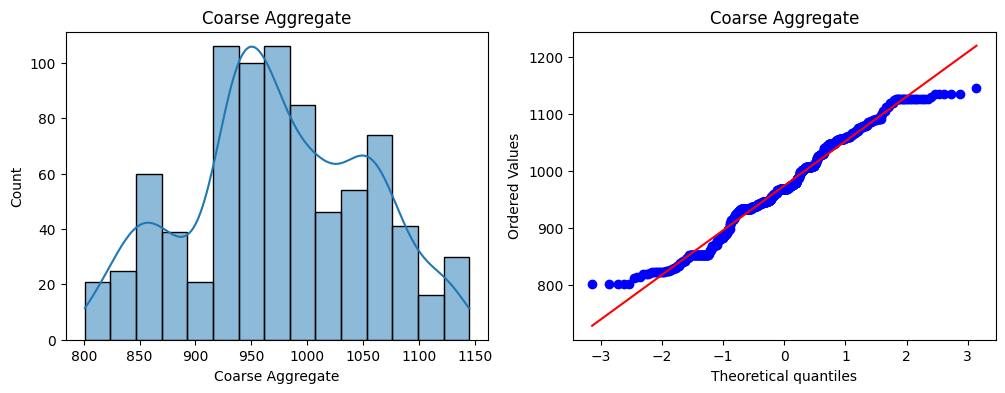

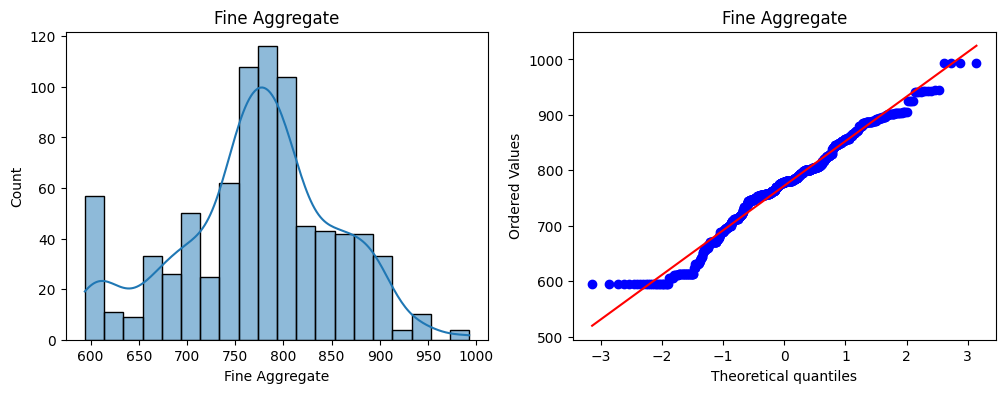

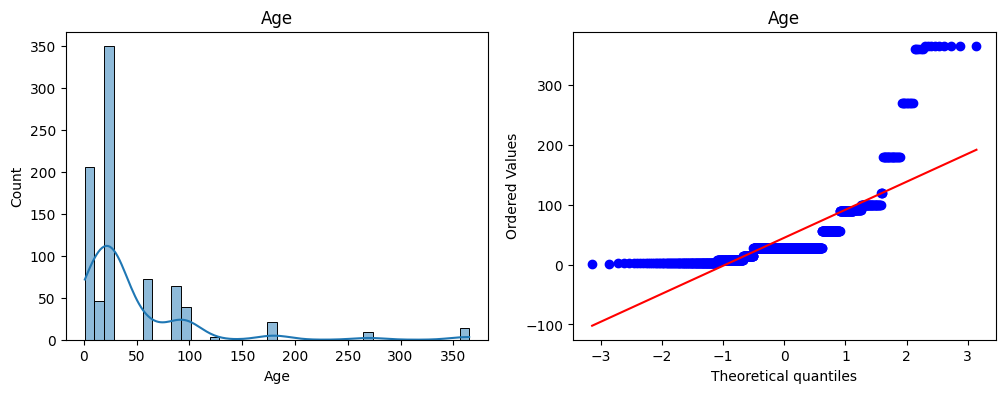

In [46]:
# lets plot all these and lets see how is the data
for col in X_train.columns:
  plt.figure(figsize=(12,4))

  plt.subplot(121)
  sns.histplot(X_train[col], kde=True)
  plt.title(col)

  plt.subplot(122)
  stats.probplot(X_train[col], dist="norm", plot=plt)
  plt.title(col)

  plt.show()

In [18]:
#  applying Box-cox transform

pt = PowerTransformer(method='box-cox')

X_train_transformed = pt.fit_transform(X_train+0.000001)
X_test_transformed = pt.fit_transform(X_test+0.000001)

pd.DataFrame({'cols': X_train.columns, 'box_cox_lambdas': pt.lambdas_})

,cols,box_cox_lambdas
0,Cement,0.215602
1,Blast Furnace Slag,0.025996
2,Fly Ash,-0.006544
3,Water,0.959062
4,Superplasticizer,0.103365
5,Coarse Aggregate,1.192492
6,Fine Aggregate,1.973781
7,Age,-0.014692


In [20]:
# again_using the linear model
lr = LinearRegression()

lr.fit(X_train_transformed, y_train)
y_pred = lr.predict(X_test_transformed)

r2_score(y_test, y_pred)

0.8055321004563973

In [22]:
# lets check it using cross val scores

pt = PowerTransformer(method='box-cox')
X_transformed = pt.fit_transform(X+0.0000001)

lr= LinearRegression()
np.mean(cross_val_score(lr,X_transformed, y, scoring='r2'))

np.float64(0.6658537935432477)

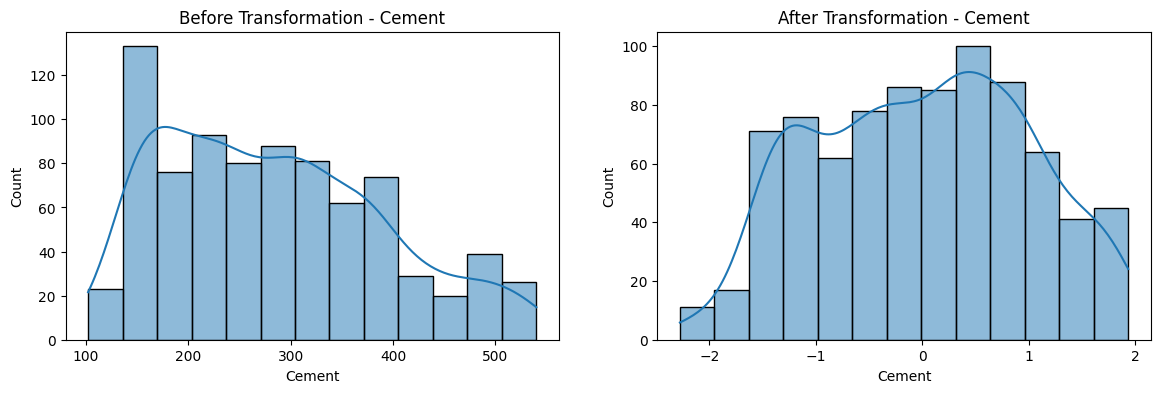

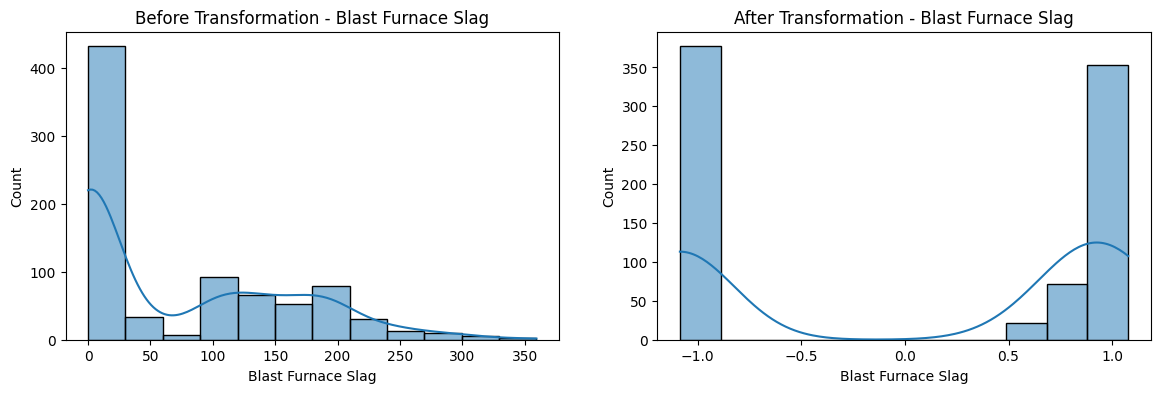

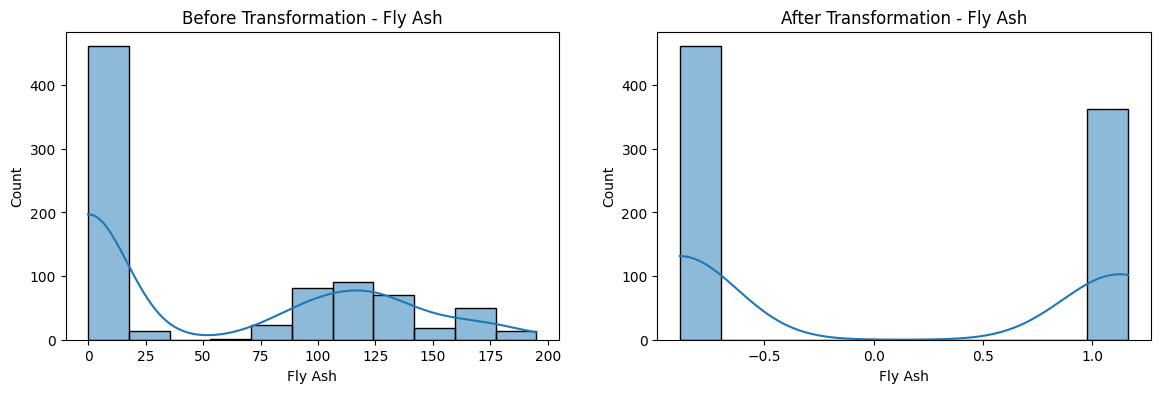

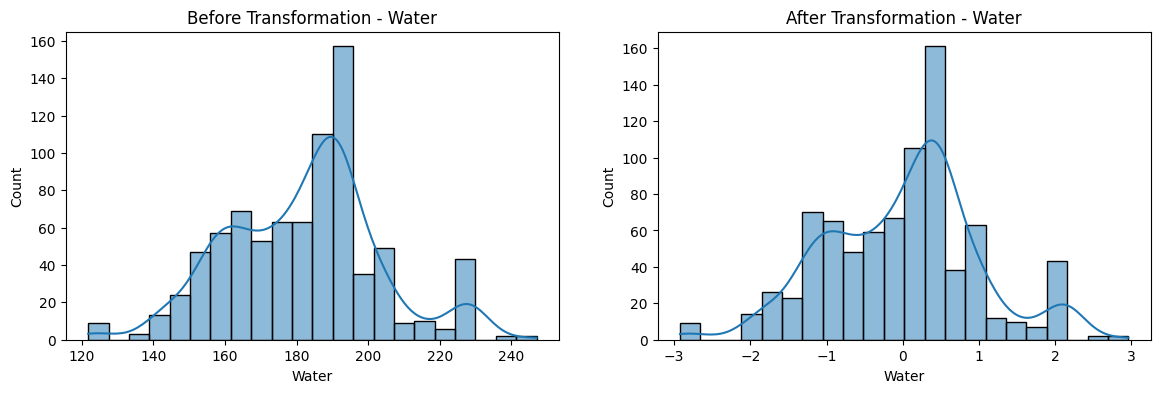

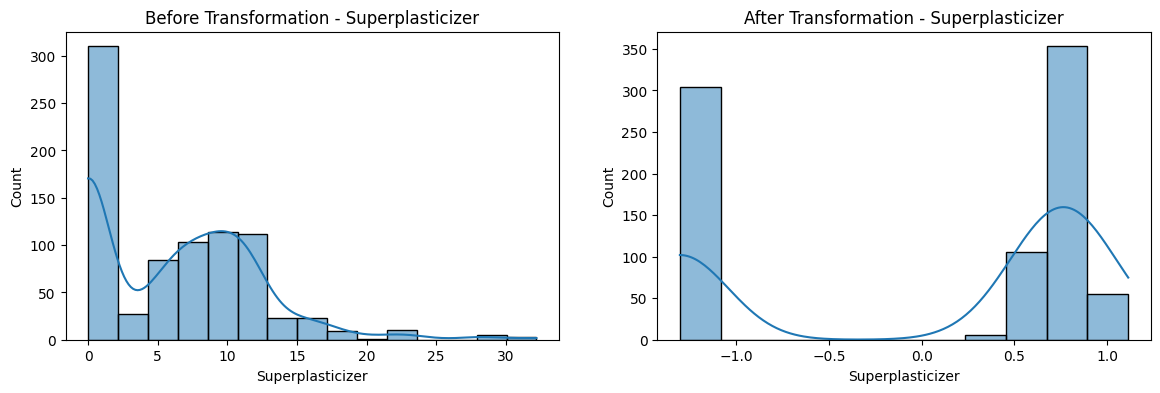

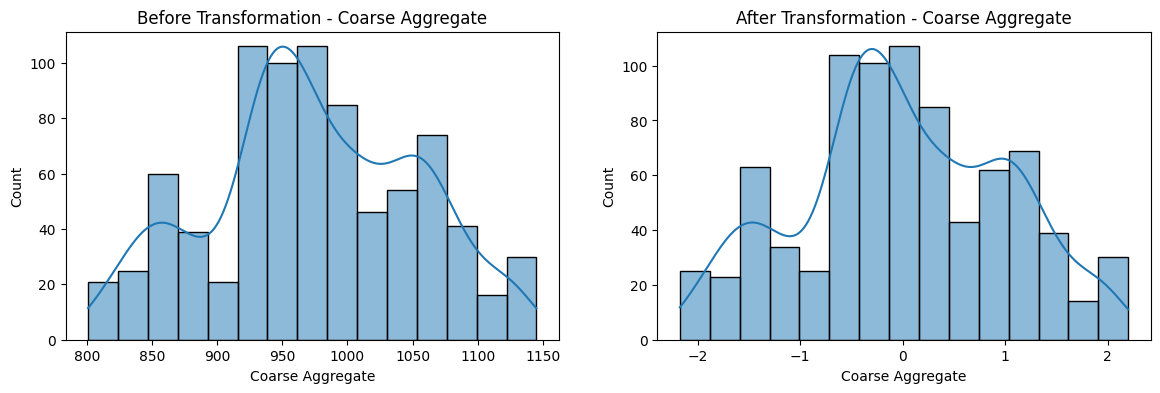

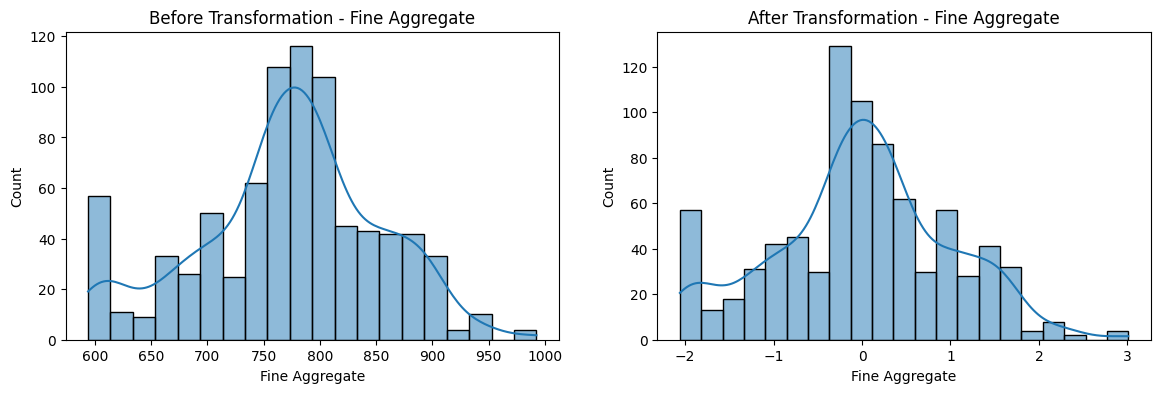

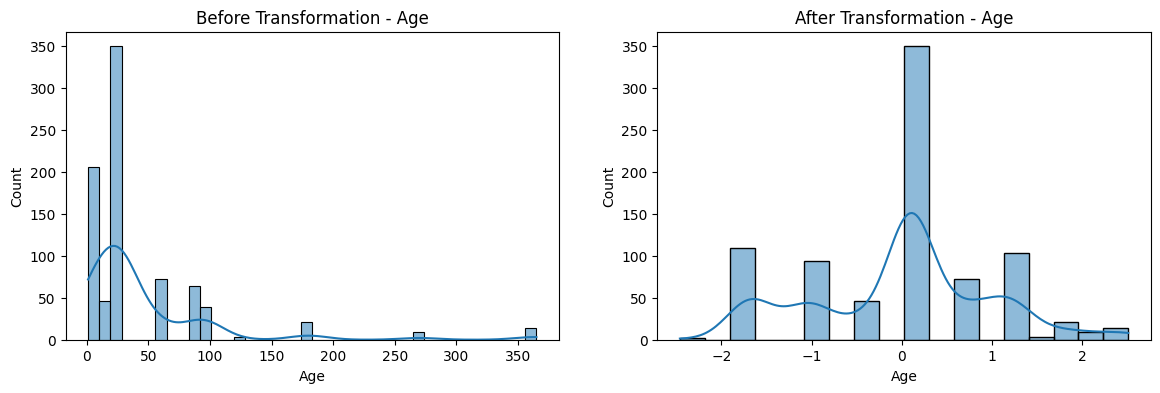

In [33]:
# lets plot a dist plot to see what really changed
# before this X_train_transformed is a numpy array need to convert into dataframe

X_train_transformed = pd.DataFrame(X_train_transformed, columns=X_train.columns)

for i, col in enumerate(X_train.columns):

    plt.figure(figsize=(14,4))

    plt.subplot(121)
    sns.histplot(X_train[col], kde=True)
    plt.title(f"Before Transformation - {col}")

    plt.subplot(122)
    sns.histplot(X_train_transformed[col], kde=True)
    plt.title(f"After Transformation - {col}")

    plt.show()

In [34]:
# applying the yeo-johnson trasnform

pt1 = PowerTransformer(method='yeo-johnson')

X_train_transformed1 = pt1.fit_transform(X_train)
X_test_transformed1 = pt1.transform(X_test)

lr = LinearRegression()
lr.fit(X_train_transformed1, y_train)
y_pred = lr.predict(X_test_transformed)

print(r2_score(y_test, y_pred))

pd.DataFrame({'cols': X_train.columns, 'yeo-johnson_lambdas': pt1.lambdas_})


0.8115241604440987


,cols,yeo-johnson_lambdas
0,Cement,0.174348
1,Blast Furnace Slag,0.015715
2,Fly Ash,-0.161447
3,Water,0.771307
4,Superplasticizer,0.253935
5,Coarse Aggregate,1.130050
6,Fine Aggregate,1.783100
7,Age,0.019885


In [36]:
# applting cross val score

pt = PowerTransformer()
X_transformed2 = pt.fit_transform(X)

lr = LinearRegression()
np.mean(cross_val_score(lr,X_transformed2,y,scoring='r2'))

np.float64(0.6834625141500866)

In [39]:
X_train_transformed1 = pd.DataFrame(X_train_transformed1,columns=X_train.columns)

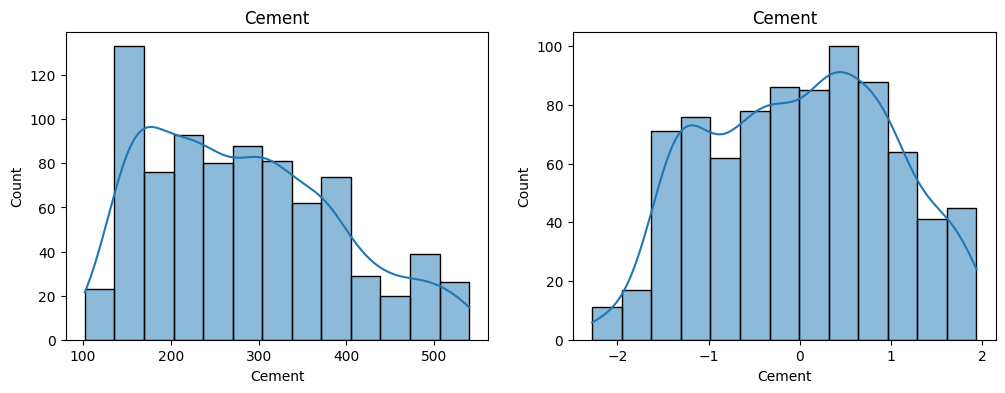

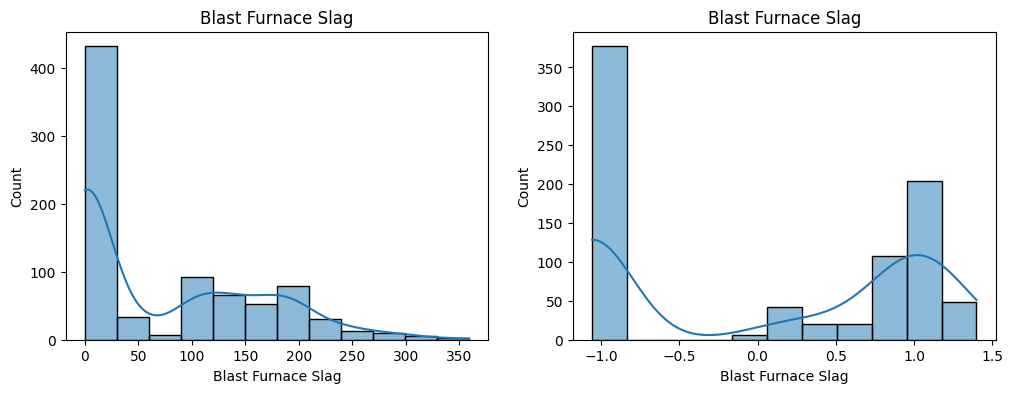

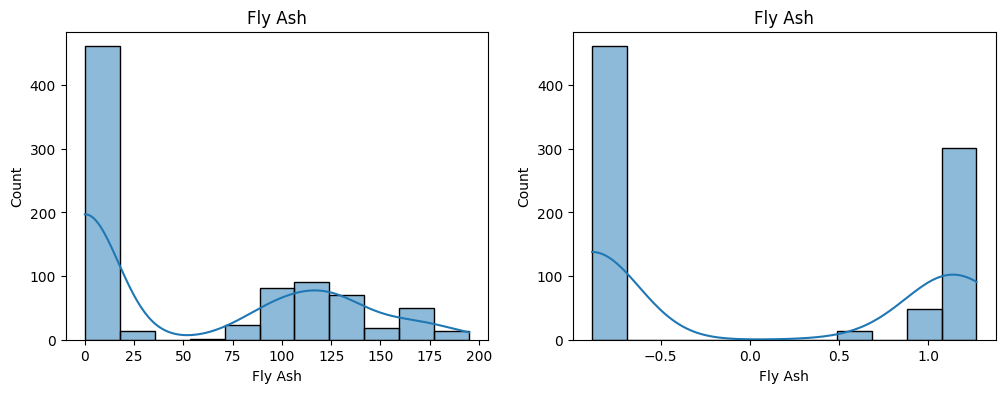

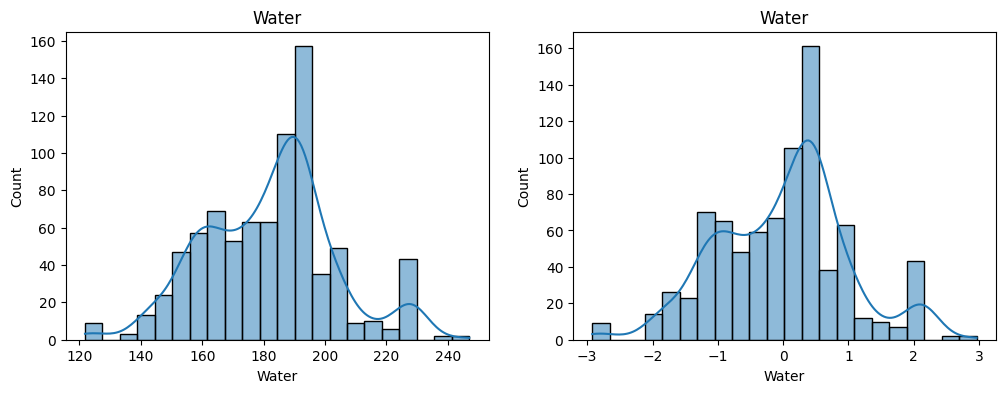

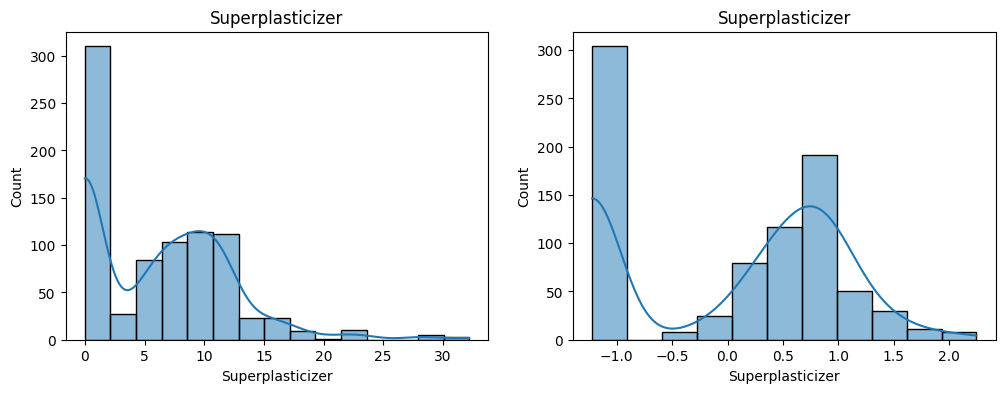

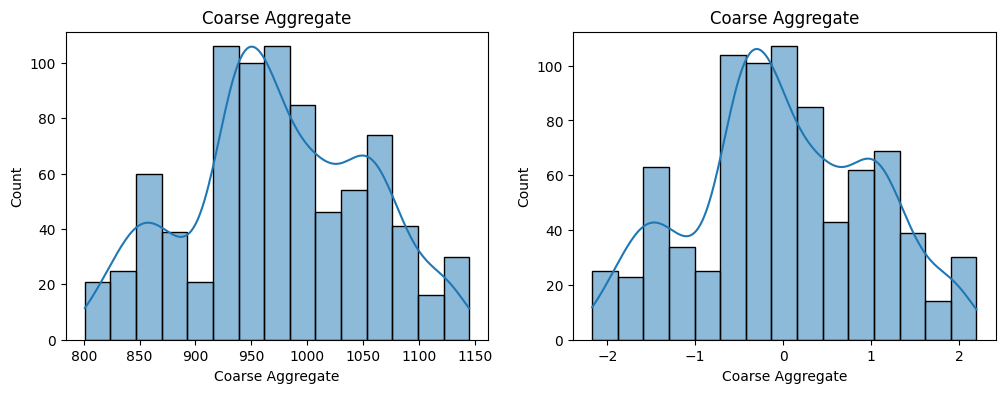

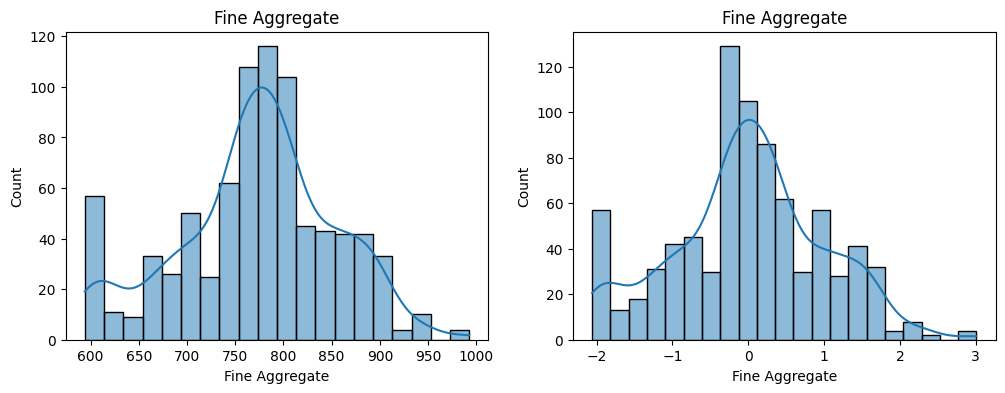

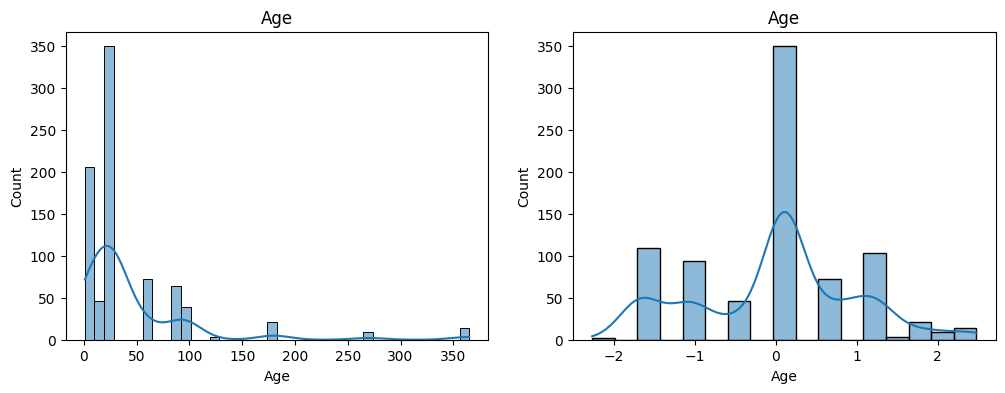

In [43]:
# before and after comparision for yeo-johnson

for col in X_train_transformed1.columns:
  plt.figure(figsize=(12,4))
  plt.subplot(121)
  sns.histplot(X_train[col], kde=True)
  plt.title(col)

  plt.subplot(122)
  sns.histplot(X_train_transformed1[col], kde=True)
  plt.title(col)

  plt.show()

In [44]:
# side by side lambdas comparison
pd.DataFrame({'cols': X_train.columns, 'box-cox_lambdas':pt.lambdas_, 'yeo-johnson':pt1.lambdas_})

,cols,box-cox_lambdas,yeo-johnson
0,Cement,0.169544,0.174348
1,Blast Furnace Slag,0.016633,0.015715
2,Fly Ash,-0.136480,-0.161447
3,Water,0.808438,0.771307
4,Superplasticizer,0.264160,0.253935
5,Coarse Aggregate,1.129395,1.130050
6,Fine Aggregate,1.830763,1.783100
7,Age,0.001771,0.019885
